# Aprendizaje automático interpretable con LIME para la clasificación de imágenes
By: Cristian Arteaga, [arteagac.github.io](https://arteagac.github.io)

![banner](https://arteagac.github.io/blog/lime_image/img/lime_banner.png)

En este post, estudiaremos cómo LIME (Local Interpretable Model-agnostic Explanations) (Ribeiro et al., 2016) genera explicaciones para tareas de clasificación de imágenes. La idea básica es entender por qué un modelo de aprendizaje automático (una red neuronal profunda) predice que una instancia (imagen) pertenece a una clase determinada (un labrador, en este caso). Para una guía introductoria sobre cómo funciona LIME, te recomiendo revisar mi publicación anterior: Aprendizaje automático interpretable con LIME. Además, el siguiente video de YouTube explica este notebook paso a paso.

In [ ]:
%%HTML
<iframe src="https://www.youtube.com/embed/ENa-w65P1xM" width="560" height="315"  allowfullscreen></iframe>

## Inicialización

### Importar
Importemos algunas utilidades de Python para la manipulación de imágenes, la visualización de gráficos y el análisis numérico.

In [ ]:
%tensorflow_version 1.x
import numpy as np
import keras
from keras.applications.imagenet_utils import decode_predictions
import skimage.io
import skimage.segmentation
import copy
import sklearn
import sklearn.metrics
from sklearn.linear_model import LinearRegression
import warnings

print('Notebook running: keras ', keras.__version__)
np.random.seed(222)

Notebook running: keras  2.3.1


### InceptionV3 inicializacion
Vamos a utilizar el modelo preentrenado InceptionV3 disponible en Keras

In [ ]:
!pip install 'h5py==2.10.0'

In [ ]:
warnings.filterwarnings('ignore')
inceptionV3_model = keras.applications.inception_v3.InceptionV3() #Load pretrained model

### Leer y preprocesar la imagen
La instancia que se va a explicar (imagen) se redimensiona y se preprocesa para que sea adecuada (compatible) con InceptionV3. Esta imagen se guarda en la variable Xi.

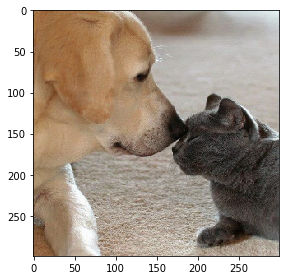

In [ ]:
Xi = skimage.io.imread("https://arteagac.github.io/blog/lime_image/img/cat-and-dog.jpg")
Xi = skimage.transform.resize(Xi, (299,299))
Xi = (Xi - 0.5)*2 #Inception pre-processing
skimage.io.imshow(Xi/2+0.5) # Show image before inception preprocessing

### Predicción de la clase de la imagen de entrada
El modelo InceptionV3 se utiliza para predecir la clase de la imagen. La salida de la clasificación es un vector de 1000 probabilidades de pertenencia a cada una de las clases disponibles en InceptionV3. Se muestra la descripción de estas clases y se puede observar que "Labrador Retriever" es la clase principal (la de mayor probabilidad) para la imagen dada.

In [ ]:
np.random.seed(222)
preds = inceptionV3_model.predict(Xi[np.newaxis,:,:,:])
decode_predictions(preds)[0] #Top 5 classes

[('n02099712', 'Labrador_retriever', 0.8273345),
 ('n02099601', 'golden_retriever', 0.014789664),
 ('n02093428', 'American_Staffordshire_terrier', 0.008711364),
 ('n02108422', 'bull_mastiff', 0.008177886),
 ('n02109047', 'Great_Dane', 0.007899425)]

Los índices (posiciones) de las 5 clases principales se guardan en la variable top_pred_classes.

In [ ]:
top_pred_classes = preds[0].argsort()[-5:][::-1]
top_pred_classes                #Index of top 5 classes

array([208, 207, 180, 243, 246])

## Explicaciones de LIME
La siguiente figura ilustra la idea básica detrás de LIME.
La imagen muestra áreas en gris claro y gris oscuro que representan las fronteras de decisión para las clases de cada par (x1, x2) en el conjunto de datos. LIME es capaz de proporcionar explicaciones para las predicciones de un registro de forma individual (el punto azul).
Las explicaciones se construyen siguiendo este flujo:
Generación de perturbaciones: Se crea un nuevo conjunto de datos con variaciones o perturbaciones alrededor de la instancia que se desea explicar (los marcadores de colores alrededor del punto azul).
Predicción de la caja negra: La salida o clase de cada perturbación generada se predice utilizando el modelo de aprendizaje automático (marcadores de colores dentro y fuera de las fronteras de decisión).
Asignación de pesos por proximidad: La importancia de cada perturbación se determina midiendo su distancia respecto a la instancia original. Estas distancias se transforman en pesos mapeándolas a una escala de cero a uno mediante una función de kernel (ver la escala de colores para los pesos).
Finalmente, toda esta información (el nuevo conjunto de datos generado, sus predicciones de clase y sus respectivos pesos) se utiliza para ajustar un modelo más simple e interpretable, como un modelo lineal (la línea azul). Los atributos de este modelo sencillo —los coeficientes, en el caso de la regresión lineal— son los que se utilizan formalmente para generar las explicaciones.

### Paso 1: Crear perturbaciones de la imagen
Para el caso de las explicaciones de imágenes, las perturbaciones se generarán activando y desactivando algunos de los superpíxeles de la imagen.

#### Crear perturbaciones de la imagen
Para el caso de las explicaciones de imágenes, las perturbaciones se generarán activando y desactivando algunos de los superpíxeles de la imagen.

In [ ]:
superpixels = skimage.segmentation.quickshift(Xi, kernel_size=4,max_dist=200, ratio=0.2)
num_superpixels = np.unique(superpixels).shape[0]
num_superpixels

68

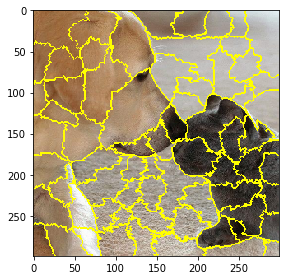

In [ ]:
skimage.io.imshow(skimage.segmentation.mark_boundaries(Xi/2+0.5, superpixels))

#### Crear perturbaciones aleatorias
En este ejemplo, se utilizaron 150 perturbaciones. Sin embargo, para aplicaciones en la vida real, un mayor número de perturbaciones producirá explicaciones más confiables.
Se generan ceros y unos de forma aleatoria y se estructuran en una matriz, donde las filas representan las perturbaciones y las columnas corresponden a los superpíxeles.
A continuación se muestra un ejemplo de perturbación (la primera de ellas). Aquí, el 1 representa que un superpíxel está activado (on) y el 0 representa que está desactivado (off). Observa que la longitud del vector mostrado corresponde exactamente al número total de superpíxeles en la imagen.

In [ ]:
num_perturb = 150
perturbations = np.random.binomial(1, 0.5, size=(num_perturb, num_superpixels))
perturbations[1] #Show example of perturbation

array([0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0])

Aquí tienes la traducción de este fragmento:
La siguiente función perturb_image perturba la imagen dada (img) basándose en un vector de perturbación (perturbation) y superpíxeles predefinidos (segments).

In [ ]:
def perturb_image(img,perturbation,segments):
  active_pixels = np.where(perturbation == 1)[0]
  mask = np.zeros(segments.shape)
  for active in active_pixels:
      mask[segments == active] = 1
  perturbed_image = copy.deepcopy(img)
  perturbed_image = perturbed_image*mask[:,:,np.newaxis]
  return perturbed_image

Usemos la función anterior para ver cómo se vería una imagen perturbada:

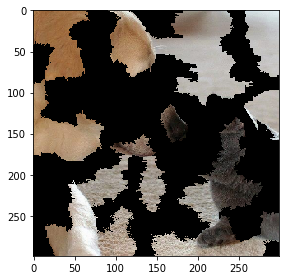

In [ ]:
skimage.io.imshow(perturb_image(Xi/2+0.5,perturbations[3],superpixels))

### Paso 2: Utilizar el clasificador de ML para predecir las clases de las nuevas imágenes generadas
Este es el paso más costoso computacionalmente en LIME porque se debe calcular una predicción para cada imagen perturbada. A partir de la forma (shape) de las predicciones, podemos ver que para cada una de las perturbaciones obtenemos la probabilidad de salida para cada una de las 1000 clases de InceptionV3.

In [ ]:
predictions = []
for pert in perturbations:
  perturbed_img = perturb_image(Xi,pert,superpixels)
  pred = inceptionV3_model.predict(perturbed_img[np.newaxis,:,:,:])
  predictions.append(pred)

predictions = np.array(predictions)
predictions.shape

(150, 1, 1000)

### Paso 3: Calcular las distancias entre la imagen original y cada una de las imágenes perturbadas, y calcular los pesos (importancia) de cada imagen perturbada
La distancia entre cada perturbación generada aleatoriamente y la imagen que se está explicando se calcula utilizando la distancia coseno.
A partir de la forma (shape) del arreglo de distancias (distances), se puede observar que, como era de esperarse, existe una distancia calculada para cada una de las perturbaciones generadas.

In [ ]:
original_image = np.ones(num_superpixels)[np.newaxis,:] #Perturbation with all superpixels enabled
distances = sklearn.metrics.pairwise_distances(perturbations,original_image, metric='cosine').ravel()
distances.shape

(150,)

#### Uso de una función kernel para calcular los pesos
Luego, las distancias se mapean a un valor entre cero y uno (el peso) utilizando una función kernel.
En el gráfico de abajo se muestra un ejemplo de una función kernel con diferentes anchos de kernel (kernel widths). Aquí, el eje X representa las distancias y el eje Y representa los pesos.
Dependiendo de cómo configuremos el ancho del kernel, este definirá qué tan amplia queremos que sea la "localidad" alrededor de nuestra instancia. Este ancho de kernel se puede establecer en función de los valores de distancia esperados. En el caso de las distancias coseno, se espera que sean relativamente estables (entre 0 y 1); por lo tanto, es posible que no se requiera un ajuste fino (fine-tuning) del ancho del kernel.

<img src="https://arteagac.github.io/blog/lime_image/img/kernel.png" alt="Drawing" width="600"/>

In [ ]:
kernel_width = 0.25
weights = np.sqrt(np.exp(-(distances**2)/kernel_width**2)) #Kernel function
weights.shape

(150,)

### Paso 4: Utilizar las perturbaciones, predicciones y pesos para ajustar un modelo explicable (lineal)
Se ajusta un modelo de regresión lineal ponderada utilizando los datos de los pasos anteriores (perturbaciones, predicciones y pesos).
Dado que la clase que queremos explicar es labrador, al ajustar el modelo lineal tomamos del vector de predicciones únicamente la columna correspondiente a la clase principal predicha.
Cada coeficiente en el modelo lineal corresponde a un superpíxel en la imagen segmentada. Estos coeficientes representan qué tan importante es cada superpíxel para la predicción de labrador.

In [ ]:
class_to_explain = top_pred_classes[0]
simpler_model = LinearRegression()
simpler_model.fit(X=perturbations, y=predictions[:,:,class_to_explain], sample_weight=weights)
coeff = simpler_model.coef_[0]
coeff

array([ 0.01998328, -0.01601374,  0.10354324, -0.04821645,  0.08925877,
        0.07826857,  0.02714023,  0.07659394,  0.18122359, -0.05638592,
        0.03509674,  0.00470361,  0.02208911,  0.10356666,  0.072237  ,
        0.00347344,  0.08162886,  0.03907233,  0.00769056,  0.02527207,
       -0.01004943,  0.02130286, -0.07029251, -0.02555164,  0.52121139,
        0.02055341,  0.00131828, -0.17025012, -0.03082532,  0.14881233,
        0.05691059,  0.10112558, -0.01224562, -0.04081403, -0.03864276,
       -0.02153396, -0.05745926,  0.02746972,  0.03796642,  0.03152464,
        0.03358096,  0.00733295,  0.04806799, -0.02303126, -0.01457861,
        0.08431813,  0.00803594, -0.01945883, -0.09000517,  0.05641922,
        0.02874266,  0.01926118, -0.03653451,  0.03901712, -0.05825459,
        0.03474161, -0.10268795,  0.00780906, -0.03470874,  0.03349185,
        0.06900844, -0.05141998,  0.02219387,  0.05436451,  0.0107227 ,
       -0.03208551,  0.09252425, -0.00573777])

In [ ]:
coeff.shape

(68,)

#### Calcular las características principales (superpíxeles)
Ahora solo necesitamos ordenar los coeficientes para identificar cuáles son los superpíxeles que tienen los mayores coeficientes (en magnitud) para la predicción de labrador. Los identificadores de estas características principales o superpíxeles se muestran a continuación.
Aunque aquí utilizamos la magnitud de los coeficientes para determinar las características más importantes, se pueden usar otras alternativas —como la selección/eliminación hacia adelante o hacia atrás (forward o backward elimination)— para la selección de la importancia de las características.

In [ ]:
num_top_features = 4
top_features = np.argsort(coeff)[-num_top_features:]
top_features

array([13, 29,  8, 24])

#### Mostrar la explicación de LIME (imagen con las características principales)
Mostremos los superpíxeles más importantes definidos en el paso anterior en una imagen, tras ocultar (o enmascarar) los superpíxeles menos relevantes.

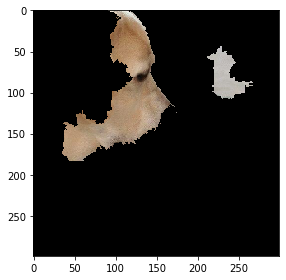

In [ ]:
mask = np.zeros(num_superpixels)
mask[top_features]= True #Activate top superpixels
skimage.io.imshow(perturb_image(Xi/2+0.5,mask,superpixels) )

Este es el paso final donde obtenemos el área de la imagen que produjo la predicción de labrador.
Puedes descargar este notebook y tal vez probar tus propias imágenes para obtener explicaciones en tus tareas de clasificación. Además, puedes usar el enlace al principio del notebook para abrirlo y probarlo en el entorno de Google Colab sin tener que instalar nada en tu computadora.